## Random Forest Model

In [53]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [54]:
df_student = pd.read_csv("data.csv", sep = ';')

In [55]:
df_student.columns = [c.strip() for c in df_student.columns]

print(df_student.shape)
df_student.head()

(4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [56]:
df_student.columns=(df_student.columns.str.strip().str.replace(r"\s+", "_", regex=True))

In [57]:
df_student.columns

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime/evening_attendance', 'Previous_qualification',
       'Previous_qualification_(grade)', 'Nacionality',
       'Mother's_qualification', 'Father's_qualification',
       'Mother's_occupation', 'Father's_occupation', 'Admission_grade',
       'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_(credited)',
       'Curricular_units_1st_sem_(enrolled)',
       'Curricular_units_1st_sem_(evaluations)',
       'Curricular_units_1st_sem_(approved)',
       'Curricular_units_1st_sem_(grade)',
       'Curricular_units_1st_sem_(without_evaluations)',
       'Curricular_units_2nd_sem_(credited)',
       'Curricular_units_2nd_sem_(enrolled)',
       'Curricular_units_2nd_sem_(evaluations)',
       'Curricular_units_2nd_sem_(approved)',
       'Curricular_units_2nd_s

In [58]:
features = [
    'Application_mode',
    'Application_order',
    'Course',
    'Daytime/evening_attendance',
    'Admission_grade',
    'Tuition_fees_up_to_date',
    'Age_at_enrollment',
    'Curricular_units_1st_sem_(enrolled)',
    'Curricular_units_1st_sem_(evaluations)',
    'Curricular_units_1st_sem_(approved)',
    'Curricular_units_1st_sem_(grade)'
]

X = df_student[features]
y = df_student['Target']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=42)

# 42 so we always get the same split when we run the code

In [60]:
X.dtypes

Application_mode                            int64
Application_order                           int64
Course                                      int64
Daytime/evening_attendance                  int64
Admission_grade                           float64
Tuition_fees_up_to_date                     int64
Age_at_enrollment                           int64
Curricular_units_1st_sem_(enrolled)         int64
Curricular_units_1st_sem_(evaluations)      int64
Curricular_units_1st_sem_(approved)         int64
Curricular_units_1st_sem_(grade)          float64
dtype: object

In [61]:
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
y_pred = forest.predict(X_test)

In [63]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7197740112994351


In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Dropout       0.78      0.70      0.74       316
    Enrolled       0.40      0.25      0.31       151
    Graduate       0.75      0.90      0.82       418

    accuracy                           0.72       885
   macro avg       0.64      0.62      0.62       885
weighted avg       0.70      0.72      0.70       885



In [65]:
from sklearn.model_selection import GridSearchCV

In [66]:
param_grid = {'n_estimators': [100, 200],'max_depth': [5, 10, 20, None]}

In [67]:
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy',n_jobs=-1)

In [68]:
grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [69]:
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 10, 'n_estimators': 200}


In [70]:
print("Best CV score:", grid_search.best_score_)

Best CV score: 0.7301444793389752


In [71]:
best_forest = grid_search.best_estimator_

In [72]:
y_pred_best = best_forest.predict(X_test)

In [73]:
accuracy_best = accuracy_score(y_test, y_pred_best)
print("Test Accuracy:", accuracy_best)

Test Accuracy: 0.7288135593220338


In [74]:
feature_importance = pd.Series(
    best_forest.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Curricular_units_1st_sem_(approved)       0.292094
Curricular_units_1st_sem_(grade)          0.173048
Tuition_fees_up_to_date                   0.102083
Admission_grade                           0.087506
Curricular_units_1st_sem_(evaluations)    0.083612
Age_at_enrollment                         0.077217
Course                                    0.063763
Curricular_units_1st_sem_(enrolled)       0.047355
Application_mode                          0.043983
Application_order                         0.022452
Daytime/evening_attendance                0.006885
dtype: float64


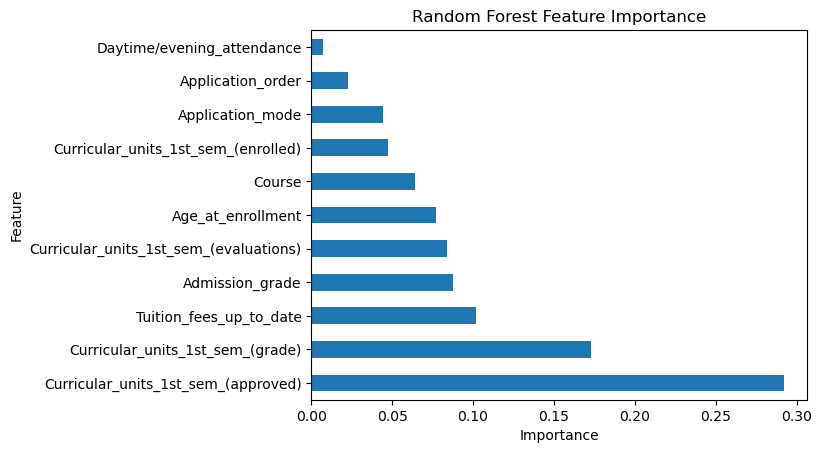

In [75]:
import matplotlib.pyplot as plt
feature_importance.plot(kind='barh')

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.show()

Our Random Forest achieved an accuracy of around 73%. The most important features were the number of approved curricular units and the first-semester grade. The model performed well for predicting Graduates and Dropouts, but it had more difficulties identifying Enrolled students

It suggests that first-semester academic performance is particularly useful for predicting students' academic outcome.

The Random Forest suggests that first-semester academic performance is particularly important for predicting students' academic outcome.

#### Conclusion

Our Random Forest model achieved around 73% accuracy. The most important predictors were related to first-semester academic performance, especially the number of approved curricular units and the first-semester grade. This suggests that early academic performance is particularly useful for predicting students' academic outcomes, including dropout.

### Model Performance
Train vs Test

In [76]:
accuracy_train = accuracy_score(y_train, best_forest.predict(X_train))
accuracy_test = accuracy_score(y_test, best_forest.predict(X_test))

print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Test Accuracy: {accuracy_test:.4f}")

Training Accuracy: 0.8779
Test Accuracy: 0.7288


In [77]:
# Confusion Matrix: shows how well the model classifies each student outcome and which classes are most frequently confused.

# Make predictions on the test set
y_pred = best_forest.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)


[[226  29  61]
 [ 43  34  74]
 [ 16  17 385]]


In [78]:
# Hiperparameter tuning: to improve generalisation and reduce overfitting
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter values to test
param_grid = {'n_estimators': [100, 150, 200],'max_depth': [3, 5, 7, 10]}

# Create the Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the models using the training data
grid_search.fit(X_train, y_train)

# Show the best parameters found
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)


Best parameters: {'max_depth': 10, 'n_estimators': 200}
Best CV accuracy: 0.7301444793389752


In [79]:
# Evaluation of the Tuned model

# Create the Random Forest using the best hyperparameters
best_forest = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

# Train the tuned model
best_forest.fit(X_train, y_train)

# Calculate accuracy on the training and test sets
accuracy_train_tuned = accuracy_score(y_train, best_forest.predict(X_train))

accuracy_test_tuned = accuracy_score(y_test, best_forest.predict(X_test))

print(f"Training Accuracy: {accuracy_train_tuned:.4f}")
print(f"Test Accuracy: {accuracy_test_tuned:.4f}")


Training Accuracy: 0.8779
Test Accuracy: 0.7288


In [80]:
# Cross-Validation Performance and Confidence Interval

from sklearn.model_selection import cross_val_score, StratifiedKFold

# Use stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate accuracy for each fold
cv_scores = cross_val_score(best_forest, X_train, y_train, cv=cv, scoring='accuracy')

# Calculate mean and standard error
mean_accuracy = cv_scores.mean()
std_accuracy = cv_scores.std()
standard_error = std_accuracy / np.sqrt(len(cv_scores))

# Calculate the 95% confidence interval
ci_lower = mean_accuracy - 1.96 * standard_error
ci_upper = mean_accuracy + 1.96 * standard_error

print("CV scores:", cv_scores)
print(f"Mean CV Accuracy: {mean_accuracy:.4f}")
print(f"95% Confidence Interval: ({ci_lower:.4f}, {ci_upper:.4f})")

CV scores: [0.72316384 0.72175141 0.74435028 0.73587571 0.72560113]
Mean CV Accuracy: 0.7301
95% Confidence Interval: (0.7226, 0.7377)


In [81]:
# Feature Importance

feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': best_forest.feature_importances_})

# Sort features from most to least important
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)

feature_importance

,Feature,Importance
9,Curricular_units_1st_sem_(approved),0.292094
10,Curricular_units_1st_sem_(grade),0.173048
5,Tuition_fees_up_to_date,0.102083
4,Admission_grade,0.087506
8,Curricular_units_1st_sem_(evaluations),0.083612
6,Age_at_enrollment,0.077217
2,Course,0.063763
7,Curricular_units_1st_sem_(enrolled),0.047355
0,Application_mode,0.043983
1,Application_order,0.022452


### Random Forest — Conclusions 

Model Performance
- Training Accuracy: 87.79%
- Test Accuracy: 72.88%
- Train–Test Gap: 14.91 percentage points. The large gap suggests that the model is overfitting.

Confusion Matrix
- The model performs best at identifying Graduate students.
- Enrolled is the most difficult class to predict correctly. Many Enrolled students are misclassified as either Graduate or Dropout.
- The model therefore has difficulties distinguishing the Enrolled class.

Hyperparameter Tuning
- Best parameters:
  - `max_depth = 10`
  - `n_estimators = 200`
- Best CV Accuracy: 73.01%
- After tuning, the Test Accuracy remained 72.88%. The selected hyperparameters did not improve the model's test performance or reduce overfitting.

Cross-Validation
- Mean CV Accuracy: 73.01%
- 95% Confidence Interval: 72.26% – 73.77%
- Test Accuracy (72.88%) is very close to the CV mean (73.01%).
- This suggests that the test performance is a fairly consistent estimate of the model's generalisation performance.

Feature Importance. The most important features are:
1. Curricular units 1st semester (approved): 29.21%
2. Curricular units 1st semester (grade): 17.30%
3. Tuition fees up to date: 10.21%
4. Admission grade: 8.75%
5. Curricular units 1st semester (evaluations): 8.36%

- First-semester academic performance is the strongest group of predictors in the model.
- Feature importance indicates predictive relevance, not causation.

**Overall Conclusion**

The Random Forest achieved around 73% accuracy on unseen data. Although the model shows signs of overfitting, cross-validation confirms a stable performance around 73%. First-semester academic performance, particularly the number of approved curricular units and grades, are the most important predictors of student outcomes.

In [82]:
# Further Hyperparameter Tuning to reduce overfitting

param_grid_2 = {'n_estimators': [100, 200],'max_depth': [5, 7, 10],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

grid_search_2 = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid_2,cv=5,scoring='accuracy',n_jobs=-1)

grid_search_2.fit(X_train, y_train)

print("Best parameters:", grid_search_2.best_params_)
print("Best CV accuracy:", grid_search_2.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 0.7304277643260695


In [83]:
# Create the Random Forest with the new best parameters
improved_forest = RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=2,min_samples_leaf=4,random_state=42)

# Train the improved model
improved_forest.fit(X_train, y_train)

# Calculate training and test accuracy
accuracy_train_improved = accuracy_score(y_train, improved_forest.predict(X_train))

accuracy_test_improved = accuracy_score(y_test, improved_forest.predict(X_test))

print(f"Training Accuracy: {accuracy_train_improved:.4f}")
print(f"Test Accuracy: {accuracy_test_improved:.4f}")
print(f"Train-Test Gap: {accuracy_train_improved - accuracy_test_improved:.4f}")

Training Accuracy: 0.8240
Test Accuracy: 0.7345
Train-Test Gap: 0.0895


In [84]:
# Perform 5-fold cross-validation on the improved model
cv_scores_improved = cross_val_score(
    improved_forest,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

# Calculate the mean accuracy and standard error
mean_accuracy_improved = cv_scores_improved.mean()
std_accuracy_improved = cv_scores_improved.std()
standard_error_improved = std_accuracy_improved / np.sqrt(len(cv_scores_improved))

# Calculate the 95% confidence interval
ci_lower_improved = mean_accuracy_improved - 1.96 * standard_error_improved
ci_upper_improved = mean_accuracy_improved + 1.96 * standard_error_improved

print("CV scores:", cv_scores_improved)
print(f"Mean CV Accuracy: {mean_accuracy_improved:.4f}")
print(f"95% Confidence Interval: ({ci_lower_improved:.4f}, {ci_upper_improved:.4f})")

CV scores: [0.72175141 0.73446328 0.75423729 0.73305085 0.72560113]
Mean CV Accuracy: 0.7338
95% Confidence Interval: (0.7240, 0.7437)


### Improved Model — Conclusions

- The improved model reduced the Training Accuracy from 87.79% to 82.40%, while increasing the Test Accuracy from 72.88% to 73.45%.
- The Train–Test Gap decreased from 14.91 to 8.95 percentage points, indicating a reduction in overfitting.
- Mean CV Accuracy increased slightly from 73.01% to 73.38%.
- The 95% Confidence Interval is 72.40% – 74.37%.
- Overall, the improved model generalises better than the previous version, although some overfitting is still present.

### Class imbalance

Before applying any balancing technique, we check the distribution of the target classes to determine whether the dataset suffers from class imbalance.

In [85]:
# Check the number of observations in each target class
print(y.value_counts())

# Check the percentage of each target class
print(y.value_counts(normalize=True) * 100)

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


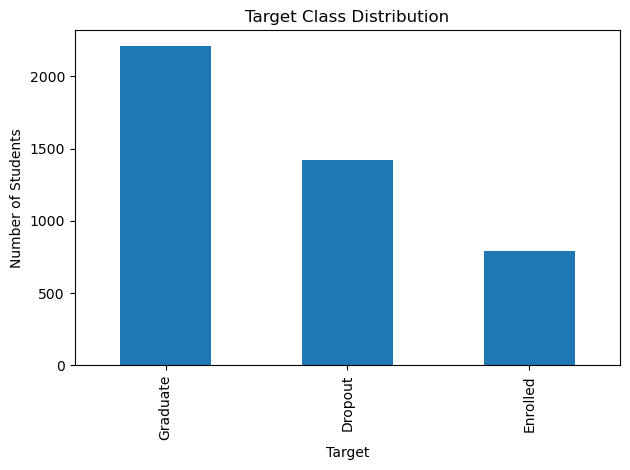

In [86]:
y.value_counts().plot(kind='bar')

plt.title('Target Class Distribution')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()

Since the target variable is imbalanced, with Enrolled being the minority class, we will apply a balancing technique to improve the model's ability to predict all classes.

In [87]:
y_train.value_counts()

Target
Graduate    1791
Dropout     1105
Enrolled     643
Name: count, dtype: int64

In [88]:
# OverSampling
from imblearn.over_sampling import RandomOverSampler

over = RandomOverSampler(random_state=42)

X_train_over, y_train_over = over.fit_resample(X_train, y_train)
y_train_over.value_counts()

Target
Dropout     1791
Enrolled    1791
Graduate    1791
Name: count, dtype: int64

In [89]:
balanced_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=4,
    random_state=42)

balanced_forest.fit(X_train_over, y_train_over)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [90]:
y_pred_balanced = balanced_forest.predict(X_test)

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)

print(f"Balanced Model Test Accuracy: {accuracy_balanced:.4f}")

Balanced Model Test Accuracy: 0.6938


In [91]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

     Dropout       0.82      0.66      0.73       316
    Enrolled       0.35      0.49      0.41       151
    Graduate       0.79      0.79      0.79       418

    accuracy                           0.69       885
   macro avg       0.65      0.65      0.64       885
weighted avg       0.72      0.69      0.70       885



In [97]:
# SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42,sampling_strategy={'Dropout': 1791,'Enrolled': 1791})
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote.value_counts()

Target
Dropout     1791
Enrolled    1791
Graduate    1791
Name: count, dtype: int64

In [98]:
smote_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=4,
    random_state=42)

smote_forest.fit(X_train_smote, y_train_smote)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [99]:
y_pred_smote = smote_forest.predict(X_test)
accuracy_smote = accuracy_score(y_test, y_pred_smote)

print(f"SMOTE Model Test Accuracy: {accuracy_smote:.4f}")

SMOTE Model Test Accuracy: 0.6723


In [100]:
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

     Dropout       0.82      0.60      0.70       316
    Enrolled       0.32      0.50      0.39       151
    Graduate       0.78      0.78      0.78       418

    accuracy                           0.67       885
   macro avg       0.64      0.63      0.63       885
weighted avg       0.72      0.67      0.69       885



In [102]:
print("Original model:", accuracy_test_improved)
print("Oversampling:", accuracy_balanced)
print("SMOTE:", accuracy_smote)

Original model: 0.7344632768361582
Oversampling: 0.6937853107344633
SMOTE: 0.672316384180791


Balancing the target classes did not improve the accuracy. Random Oversampling reduced the test accuracy from 73.45% to 69.38%, while SMOTE reduced it to 67.23%.

However, balancing improved the detection of the minority class, Enrolled, increasing its recall to around 49–50%. Therefore, balancing improves the model's ability to identify the minority class, but at the cost of lower overall accuracy.